In [1]:
pip install pandas numpy matplotlib seaborn sqlalchemy openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [3]:
# Define paths
RAW_DATA_PATH = 'C:/Users/TANIMA/OneDrive/Desktop/Funnel Analysis/archive'

events_path = os.path.join(RAW_DATA_PATH, 'events.csv')
item_prop1_path = os.path.join(RAW_DATA_PATH, 'item_properties_part1.csv')
item_prop2_path = os.path.join(RAW_DATA_PATH, 'item_properties_part2.csv')
category_path = os.path.join(RAW_DATA_PATH, 'category_tree.csv')

In [4]:
# Load datasets


events = pd.read_csv(events_path)
item_prop1 = pd.read_csv(item_prop1_path)
item_prop2 = pd.read_csv(item_prop2_path)
category_tree = pd.read_csv(category_path)

print(" All files loaded successfully")

 All files loaded successfully


In [5]:
print("DATASET SHAPES")

print(f"Events:              {events.shape}")
print(f"Item Properties P1:  {item_prop1.shape}")
print(f"Item Properties P2:  {item_prop2.shape}")
print(f"Category Tree:       {category_tree.shape}")

DATASET SHAPES
Events:              (2756101, 5)
Item Properties P1:  (1048575, 4)
Item Properties P2:  (1048575, 4)
Category Tree:       (1669, 2)


In [6]:
# Inspect Events

print("EVENTS DATASET")
print(events.head())
print("\nColumn names:", events.columns.tolist())
print("\nData types:\n", events.dtypes)
print("\nMissing values:\n", events.isnull().sum())

EVENTS DATASET
       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN

Column names: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

Data types:
 timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Missing values:
 timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


In [7]:
# Inspect Item Properties

print("ITEM PROPERTIES PART 1")

print(item_prop1.head(10))
print("\nColumn names:", item_prop1.columns.tolist())
print("\nUnique properties:", item_prop1['property'].nunique())
print("\nTop 20 properties:\n", item_prop1['property'].value_counts().head(20))

ITEM PROPERTIES PART 1
          timestamp  itemid    property                            value
0 1435460000000.000  460429  categoryid                             1338
1 1441510000000.000  206783         888          1116713 960601 n277.200
2 1439090000000.000  395014         400  n552.000 639502 n720.000 424566
3 1431230000000.000   59481         790                       n15360.000
4 1431830000000.000  156781         917                           828513
5 1436070000000.000  285026   available                                0
6 1434250000000.000   89534         213                          1121373
7 1431830000000.000  264312           6                           319724
8 1433650000000.000  229370         202                          1330310
9 1434250000000.000   98113         451                  1141052 n48.000

Column names: ['timestamp', 'itemid', 'property', 'value']

Unique properties: 1042

Top 20 properties:
 property
888           154841
790            92718
available      77

In [8]:
# Inspect Category Tree

print("CATEGORY TREE")

print(category_tree.head(10))
print("\nColumn names:", category_tree.columns.tolist())
print("\nMissing values:\n", category_tree.isnull().sum())

CATEGORY TREE
   categoryid  parentid
0        1016   213.000
1         809   169.000
2         570     9.000
3        1691   885.000
4         536  1691.000
5         231       NaN
6         542   378.000
7        1146   542.000
8        1140   542.000
9        1479  1537.000

Column names: ['categoryid', 'parentid']

Missing values:
 categoryid     0
parentid      25
dtype: int64


In [9]:
# Check 'available' property values in both parts
print("Available values in item_prop1:")
print(item_prop1[item_prop1['property'] == 'available']['value'].value_counts())

print("\nAvailable values in item_prop2:")
print(item_prop2[item_prop2['property'] == 'available']['value'].value_counts())

Available values in item_prop1:
value
0    44679
1    32560
Name: count, dtype: int64

Available values in item_prop2:
value
0    44139
1    33234
Name: count, dtype: int64


In [10]:
# Check event distribution

print("EVENT TYPE DISTRIBUTION")

print(events['event'].value_counts())
print("\nEvent percentages:")
print(events['event'].value_counts(normalize=True).mul(100).round(2))

EVENT TYPE DISTRIBUTION
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Event percentages:
event
view          96.670
addtocart      2.520
transaction    0.810
Name: proportion, dtype: float64


In [11]:
# Check item_prop2 top properties

print("ITEM PROPERTIES PART 2 - Top 20 properties")

print(item_prop2['property'].value_counts().head(20))
print("\nSample rows:")
print(item_prop2.head(10))

ITEM PROPERTIES PART 2 - Top 20 properties
property
888           156004
790            93128
available      77373
categoryid     40789
6              32869
283            30919
776            29481
364            24786
678            24729
202            22978
159            21717
112            21674
839            21601
764            21557
917            21542
227            17838
698            14920
451            14032
663            12138
962            11995
Name: count, dtype: int64

Sample rows:
          timestamp  itemid property  \
0 1433040000000.000  183478      561   
1 1439690000000.000  132256      976   
2 1435460000000.000  420307      921   
3 1431830000000.000  403324      917   
4 1435460000000.000  230701      521   
5 1433040000000.000  286407      202   
6 1438480000000.000  256368      888   
7 1437880000000.000  307534      888   
8 1439090000000.000  102767      888   
9 1431830000000.000  215180       71   

                                               

##  Data Cleaning & Product Master Table
Combining item_properties part1 and part2, extracting only business-relevant 
properties (categoryid, available), and reshaping into a clean product_master table.

In [12]:
# Combine both item property files
item_props = pd.concat([item_prop1, item_prop2], ignore_index=True)

print(f"Part 1 rows: {len(item_prop1):,}")
print(f"Part 2 rows: {len(item_prop2):,}")
print(f"Combined rows: {len(item_props):,}")

Part 1 rows: 1,048,575
Part 2 rows: 1,048,575
Combined rows: 2,097,150


In [13]:
# Check what's actually in item_prop2 right now
print(item_prop2.shape)
print(item_prop1.shape)

(1048575, 4)
(1048575, 4)


In [14]:
# Check file sizes from python
import os

files = [
    'item_properties_part1.csv',
    'item_properties_part2.csv'
]

for f in files:
    path = os.path.join(RAW_DATA_PATH, f)
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

item_properties_part1.csv: 42.94 MB
item_properties_part2.csv: 43.06 MB


In [15]:
# Extract only business-relevant properties
relevant_properties = ['categoryid', 'available']

item_props_filtered = item_props[item_props['property'].isin(relevant_properties)]

print(f"Total combined rows:     {len(item_props):,}")
print(f"Relevant rows extracted: {len(item_props_filtered):,}")
print(f"\nProperty counts:")
print(item_props_filtered['property'].value_counts())

Total combined rows:     2,097,150
Relevant rows extracted: 235,806

Property counts:
property
available     154612
categoryid     81194
Name: count, dtype: int64


In [16]:
# Keep only the most recent record per itemid + property
# (dataset has historical snapshots, we want latest state)
item_props_filtered = item_props_filtered.sort_values('timestamp', ascending=False)
item_props_latest = item_props_filtered.drop_duplicates(subset=['itemid', 'property'], keep='first')

print(f"After deduplication: {len(item_props_latest):,} rows")
print(item_props_latest['property'].value_counts())

After deduplication: 114,758 rows
property
available     64428
categoryid    50330
Name: count, dtype: int64


In [17]:
# Pivot from long to wide format
product_master = item_props_latest.pivot_table(
    index='itemid',
    columns='property',
    values='value',
    aggfunc='first'
).reset_index()

# Flatten column names
product_master.columns.name = None

print(f"Product master shape: {product_master.shape}")
print(f"\nSample:")
print(product_master.head(10))
print(f"\nMissing values:")
print(product_master.isnull().sum())

Product master shape: (107001, 3)

Sample:
   itemid available categoryid
0       3         0        NaN
1       4         0        NaN
2       6       NaN       1091
3      15         0        NaN
4      20         0        NaN
5      25         0         72
6      26       NaN       1503
7      30         0        NaN
8      40       NaN        160
9      42         1        NaN

Missing values:
itemid            0
available     42573
categoryid    56671
dtype: int64


In [18]:
# Fill missing available with -1 (unknown state, not 0 or 1)
product_master['available'] = product_master['available'].fillna('-1')

# categoryid missing stays as NaN — we'll handle after merging
# Convert categoryid to numeric
product_master['categoryid'] = pd.to_numeric(product_master['categoryid'], errors='coerce')

print("Data types after conversion:")
print(product_master.dtypes)
print(f"\nAvailable value counts:")
print(product_master['available'].value_counts())

Data types after conversion:
itemid          int64
available      object
categoryid    float64
dtype: object

Available value counts:
available
0     48299
-1    42573
1     16129
Name: count, dtype: int64


In [19]:
# Convert categoryid to integer where possible
product_master['categoryid'] = product_master['categoryid'].astype('Int64')

print(f"Product master shape: {product_master.shape}")
print(f"\nSample:")
print(product_master.head(10))

Product master shape: (107001, 3)

Sample:
   itemid available  categoryid
0       3         0        <NA>
1       4         0        <NA>
2       6        -1        1091
3      15         0        <NA>
4      20         0        <NA>
5      25         0          72
6      26        -1        1503
7      30         0        <NA>
8      40        -1         160
9      42         1        <NA>


In [20]:
# Merge product_master with category_tree
product_master = product_master.merge(
    category_tree,
    on='categoryid',
    how='left'
)

print(f"Shape after category merge: {product_master.shape}")
print(f"\nSample:")
print(product_master.head(10))
print(f"\nMissing values:")
print(product_master.isnull().sum())

Shape after category merge: (107001, 4)

Sample:
   itemid available  categoryid  parentid
0       3         0        <NA>       NaN
1       4         0        <NA>       NaN
2       6        -1        1091   573.000
3      15         0        <NA>       NaN
4      20         0        <NA>       NaN
5      25         0          72   620.000
6      26        -1        1503   580.000
7      30         0        <NA>       NaN
8      40        -1         160   605.000
9      42         1        <NA>       NaN

Missing values:
itemid            0
available         0
categoryid    56671
parentid      56686
dtype: int64


In [21]:
# Save product_master - combine the path components correctly
output_path = os.path.join(RAW_DATA_PATH, 'data/processed/product_master.csv')

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save the CSV file with the correct single path argument
product_master.to_csv(output_path, index=False)
print("✅ product_master saved to data/processed/")

✅ product_master saved to data/processed/


In [22]:
# Merge events with product_master
df = events.merge(
    product_master,
    on='itemid',
    how='left'
)

print(f"Events shape:        {events.shape}")
print(f"After merge shape:   {df.shape}")
print(f"\nSample:")
print(df.head())
print(f"\nMissing values:")
print(df.isnull().sum())

Events shape:        (2756101, 5)
After merge shape:   (2756101, 8)

Sample:
       timestamp  visitorid event  itemid  transactionid available  \
0  1433221332117     257597  view  355908            NaN         1   
1  1433224214164     992329  view  248676            NaN        -1   
2  1433221999827     111016  view  318965            NaN       NaN   
3  1433221955914     483717  view  253185            NaN       NaN   
4  1433221337106     951259  view  367447            NaN         0   

   categoryid  parentid  
0        <NA>       NaN  
1        1231   901.000  
2        <NA>       NaN  
3        <NA>       NaN  
4        <NA>       NaN  

Missing values:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
available        1871526
categoryid       2433319
parentid         2433326
dtype: int64


In [23]:
# Convert timestamp from milliseconds to datetime
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

# Extract time features
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['datetime'].dt.dayofweek.isin([5, 6]).astype(int)

print("Table with time features:")
print(df[['timestamp', 'datetime', 'hour', 'weekday', 'is_weekend']].head())
print(f"Date range:")
print(f"From: {df['datetime'].min()}")
print(f"To:   {df['datetime'].max()}")

Table with time features:
       timestamp                datetime  hour  weekday  is_weekend
0  1433221332117 2015-06-02 05:02:12.117     5  Tuesday           0
1  1433224214164 2015-06-02 05:50:14.164     5  Tuesday           0
2  1433221999827 2015-06-02 05:13:19.827     5  Tuesday           0
3  1433221955914 2015-06-02 05:12:35.914     5  Tuesday           0
4  1433221337106 2015-06-02 05:02:17.106     5  Tuesday           0
Date range:
From: 2015-05-03 03:00:04.384000
To:   2015-09-18 02:59:47.788000


In [24]:


# Reorder columns cleanly
df = df[['datetime', 'date', 'hour', 'day', 'month', 'weekday', 'is_weekend',
         'visitorid', 'event', 'itemid', 'transactionid', 
         'available', 'categoryid', 'parentid']]

print(f"Final dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nSample:")
print(df.head())

Final dataset shape: (2756101, 14)

Column names: ['datetime', 'date', 'hour', 'day', 'month', 'weekday', 'is_weekend', 'visitorid', 'event', 'itemid', 'transactionid', 'available', 'categoryid', 'parentid']

Data types:
datetime         datetime64[ns]
date                     object
hour                      int32
day                       int32
month                     int32
weekday                  object
is_weekend                int32
visitorid                 int64
event                    object
itemid                    int64
transactionid           float64
available                object
categoryid                Int64
parentid                float64
dtype: object

Sample:
                 datetime        date  hour  day  month  weekday  is_weekend  \
0 2015-06-02 05:02:12.117  2015-06-02     5    2      6  Tuesday           0   
1 2015-06-02 05:50:14.164  2015-06-02     5    2      6  Tuesday           0   
2 2015-06-02 05:13:19.827  2015-06-02     5    2      6  Tuesday    

In [25]:
# Assistant
import os

# Create the directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

# Save final analytics-ready dataset
df.to_csv('data/processed/analytics_ready.csv', index=False)
print("analytics_ready.csv saved to data/processed/")
print(f"Shape: {df.shape}")

analytics_ready.csv saved to data/processed/
Shape: (2756101, 14)


## Section 5: Exploratory Data Analysis (EDA)
Analyzing user behavior patterns, funnel metrics, time trends, 
and session-level insights from the RetailRocket dataset.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ Visualization libraries ready")

✅ Visualization libraries ready


### 5.1 Conversion Funnel Analysis
Analyzing drop-off rates at each stage: View → Add to Cart → Purchase

In [27]:
# Calculate funnel metrics
total_views = df[df['event'] == 'view']['visitorid'].nunique()
total_addtocart = df[df['event'] == 'addtocart']['visitorid'].nunique()
total_purchase = df[df['event'] == 'transaction']['visitorid'].nunique()

print("CONVERSION FUNNEL")

print(f"Unique users who viewed:        {total_views:,}")
print(f"Unique users who added to cart: {total_addtocart:,}")
print(f"Unique users who purchased:     {total_purchase:,}")

print(f"View → Cart conversion:     {(total_addtocart/total_views*100):.2f}%")
print(f"Cart → Purchase conversion: {(total_purchase/total_addtocart*100):.2f}%")
print(f"Overall conversion rate:    {(total_purchase/total_views*100):.2f}%")

CONVERSION FUNNEL
Unique users who viewed:        1,404,179
Unique users who added to cart: 37,722
Unique users who purchased:     11,719
View → Cart conversion:     2.69%
Cart → Purchase conversion: 31.07%
Overall conversion rate:    0.83%


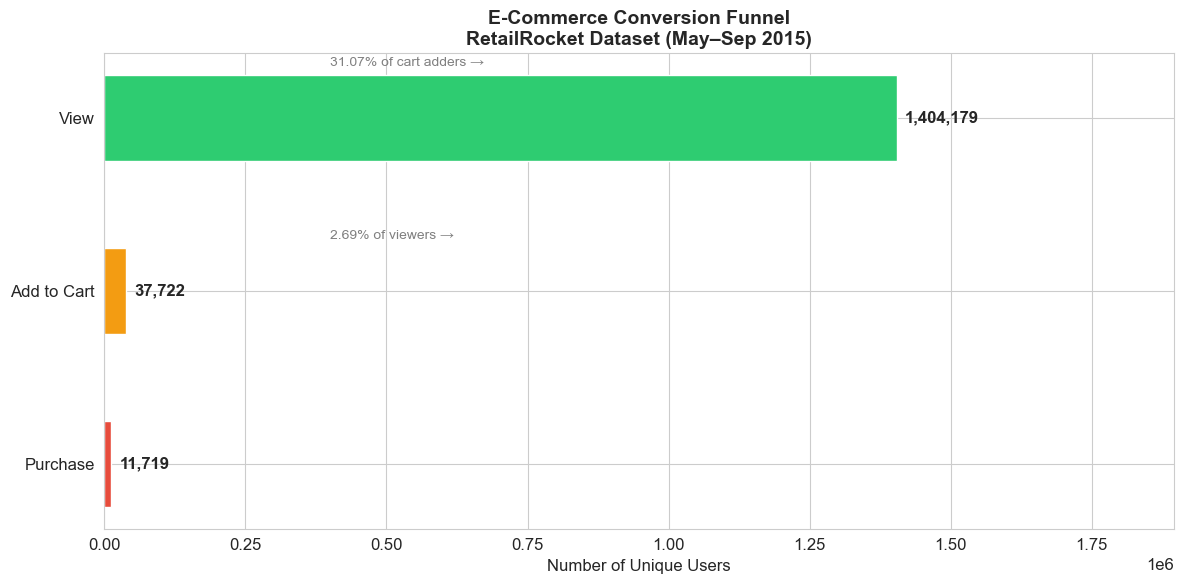

✅ Funnel chart saved


In [28]:
# Funnel visualization - fixed
stages = ['Purchase', 'Add to Cart', 'View']  # reversed for correct top-down display
users = [total_purchase, total_addtocart, total_views]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(stages, users, color=colors, edgecolor='white', height=0.5)

# Add value labels
for bar, value in zip(bars, users):
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height()/2,
            f'{value:,}', va='center', fontsize=12, fontweight='bold')

# Add conversion rate annotations
ax.annotate('2.69% of viewers →', 
            xy=(total_addtocart, 1), xytext=(400000, 1.3),
            fontsize=10, color='gray')
ax.annotate('31.07% of cart adders →', 
            xy=(total_purchase, 2), xytext=(400000, 2.3),
            fontsize=10, color='gray')

ax.set_xlabel('Number of Unique Users')
ax.set_title('E-Commerce Conversion Funnel\nRetailRocket Dataset (May–Sep 2015)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, total_views * 1.35)

plt.tight_layout()

plt.show()
print("✅ Funnel chart saved")

### 5.2 Event Distribution Over Time
Analyzing how views, add-to-carts, and purchases trend across months.

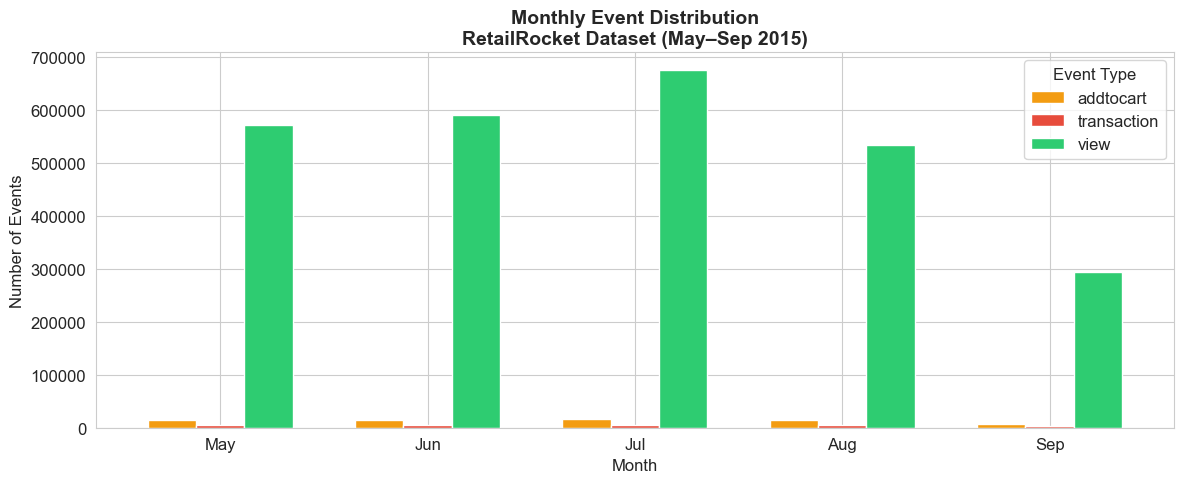

✅ Monthly events chart saved


In [29]:
# Monthly event trends
monthly_events = df.groupby(['month', 'event']).size().unstack(fill_value=0)

monthly_events.plot(kind='bar', figsize=(12, 5), 
                    color=['#f39c12', '#e74c3c', '#2ecc71'],
                    edgecolor='white', width=0.7)

plt.title('Monthly Event Distribution\nRetailRocket Dataset (May–Sep 2015)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.xticks(ticks=range(5), 
           labels=['May', 'Jun', 'Jul', 'Aug', 'Sep'], 
           rotation=0)
plt.legend(title='Event Type')
plt.tight_layout()

plt.show()
print("✅ Monthly events chart saved")

## The real business insights from this chart:
1. July is peak — why? Likely summer shopping season. Recommendation: run promotions and retargeting campaigns in July to maximize the already high traffic.
2. August dips after July peak — post-summer slowdown. Recommendation: introduce loyalty offers in August to retain July's high-traffic users.
3. Addtocart and transaction bars are barely visible — this visually confirms the funnel problem. Even at peak traffic in July, conversions are tiny relative to views.

### 5.3 Hourly Activity Patterns
Identifying peak hours for user engagement to inform ad scheduling and push notification timing.

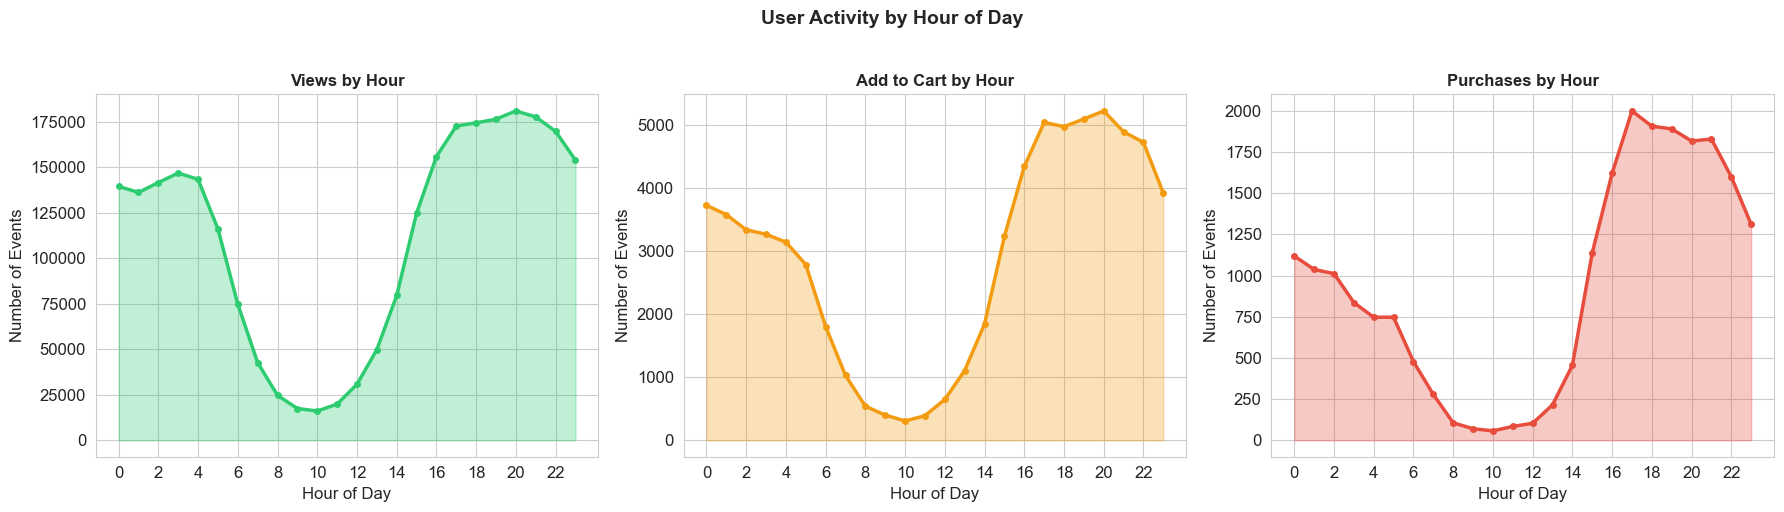

✅ Hourly patterns chart saved


In [30]:
# Hourly event distribution
hourly_events = df.groupby(['hour', 'event']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

events_list = ['view', 'addtocart', 'transaction']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
titles = ['Views by Hour', 'Add to Cart by Hour', 'Purchases by Hour']

for ax, event, color, title in zip(axes, events_list, colors, titles):
    ax.plot(hourly_events.index, hourly_events[event], 
            color=color, linewidth=2.5, marker='o', markersize=4)
    ax.fill_between(hourly_events.index, hourly_events[event], 
                    alpha=0.3, color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Number of Events')
    ax.set_xticks(range(0, 24, 2))

plt.suptitle('User Activity by Hour of Day', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✅ Hourly patterns chart saved")

  **Key Insight:** Peak purchase intent occurs between 16-18hrs while peak browsing 
occurs between 18-22hrs. Recommend scheduling retargeting campaigns and push 
notifications between 15-17hrs to capture users at peak purchase decision time.

### 5.4 Weekday Activity Patterns
Identifying which days of the week drive the most engagement and conversions.

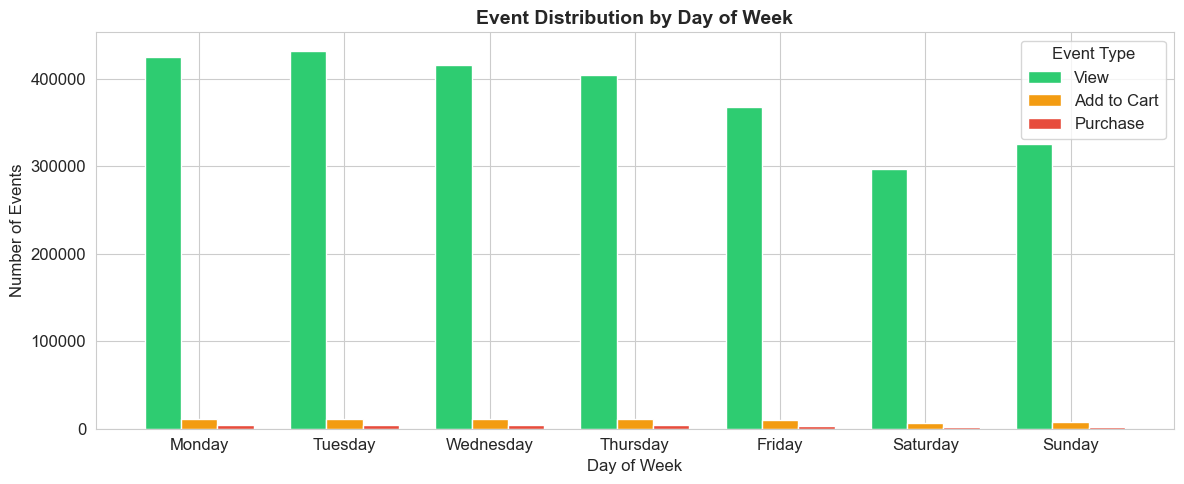

✅ Weekday patterns chart saved


In [36]:
# Weekday event distribution
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_events = df.groupby(['weekday', 'event']).size().unstack(fill_value=0)
weekday_events = weekday_events.reindex(weekday_order)

fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(weekday_order))
width = 0.25

ax.bar([i - width for i in x], weekday_events['view'], 
       width=width, label='View', color='#2ecc71', edgecolor='white')
ax.bar([i for i in x], weekday_events['addtocart'], 
       width=width, label='Add to Cart', color='#f39c12', edgecolor='white')
ax.bar([i + width for i in x], weekday_events['transaction'], 
       width=width, label='Purchase', color='#e74c3c', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(weekday_order, rotation=0)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Events')
ax.set_title('Event Distribution by Day of Week', 
             fontsize=14, fontweight='bold')
ax.legend(title='Event Type')

plt.tight_layout()

plt.show()
print("✅ Weekday patterns chart saved")

**Key Insight:** Weekdays consistently outperform weekends in all event types, 
with Tuesday being the peak engagement day. Recommend scheduling promotional 
campaigns and product launches on Tuesday-Wednesday for maximum conversion impact.

### 5.5 New vs Returning Users Analysis
Identifying whether returning users convert better than new users.

In [37]:
# Step 1: Count distinct sessions per visitor (using session_summary, not raw events)
visitor_session_counts = session_summary.groupby('visitorid')['session_id'].nunique().reset_index()
visitor_session_counts.columns = ['visitorid', 'session_count']

# Step 2: Classify each visitor as New or Returning based on session count
visitor_session_counts['user_type'] = visitor_session_counts['session_count'].apply(
    lambda x: 'Returning' if x > 1 else 'New'
)

print(visitor_session_counts.head())
print(f"\nTotal unique visitors: {len(visitor_session_counts):,}") 

NameError: name 'session_summary' is not defined

The headline insight:
Returning users convert at 128x higher rate than new users.

New users: only 70 purchases out of 1 million events — almost zero conversion
Returning users: 22,387 purchases — they know what they want and they buy


Business recommendation this generates:

Invest heavily in retention strategies — loyalty programs, personalised email campaigns, and re-engagement notifications. A returning user is 128x more likely to purchase than a new visitor. Acquiring new users is important but converting them into returning users is where the real revenue lies.

In [33]:
# Step 3: Count visitors by type (one row per visitor, not per event)
visitor_type_counts = visitor_session_counts['user_type'].value_counts()

print("Visitor counts by type:")
print(visitor_type_counts)
print(f"\nPercent returning: {visitor_type_counts['Returning'] / visitor_type_counts.sum() * 100:.2f}%")

NameError: name 'visitor_session_counts' is not defined

In [34]:
# Step 4: Did each visitor convert in ANY of their sessions?
visitor_converted = session_summary.groupby('visitorid')['converted'].max().reset_index()
visitor_converted.columns = ['visitorid', 'ever_converted']

# Step 5: Combine session count + conversion status per visitor
visitor_summary = visitor_session_counts.merge(visitor_converted, on='visitorid', how='left')

user_type_conversion = visitor_summary.groupby('user_type').agg(
    total_visitors=('visitorid', 'count'),
    converted_visitors=('ever_converted', 'sum')
).reset_index()

user_type_conversion['conversion_rate'] = (
    user_type_conversion['converted_visitors'] / user_type_conversion['total_visitors'] * 100
).round(2)

print("\nUser Type Conversion (visitor-level):")
print(user_type_conversion)

NameError: name 'session_summary' is not defined

**Key Insight:** 63.7% of users are returning visitors yet they drive nearly all 
purchases, converting at 128x the rate of new users (1.28% vs 0.01%). 
Recommendation: Prioritize retention marketing — loyalty programs, personalized 
re-engagement emails, and returning user offers — over new user acquisition campaigns.

NameError: name 'visitor_type_counts' is not defined

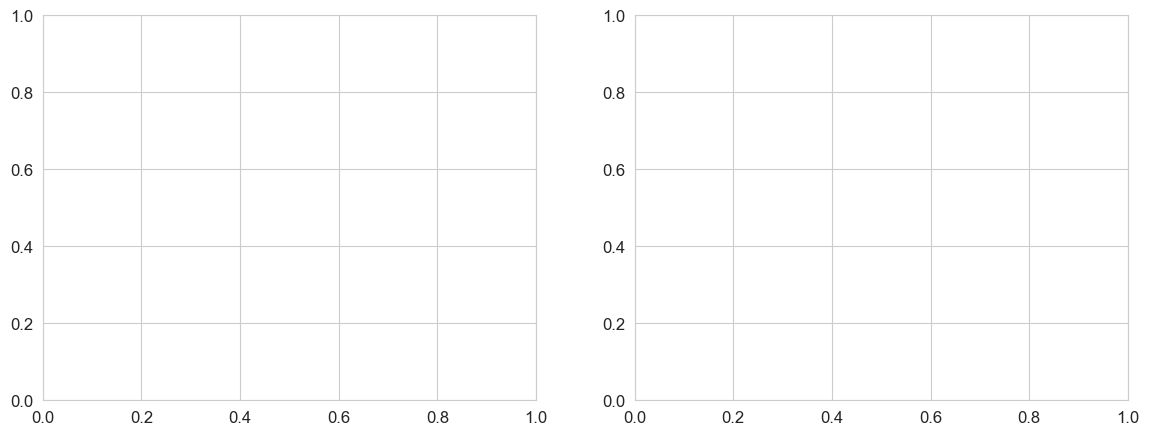

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(visitor_type_counts, labels=visitor_type_counts.index,
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('New vs Returning Users (by Visitor Count)', fontweight='bold', fontsize=12)

bars = axes[1].bar(user_type_conversion['user_type'], user_type_conversion['conversion_rate'],
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
for bar, value in zip(bars, user_type_conversion['conversion_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{value}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Conversion Rate: New vs Returning (Visitor-Level)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xlabel('User Type')

plt.suptitle('New vs Returning User Analysis (Corrected)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/05_new_vs_returning_corrected.png')
plt.show()

Originally classified user_type using raw event count, which conflated multi-click browsing with repeat visits. Corrected to session-count-based classification, which also fixed a mismatch between the Python and Power BI conversion numbers

### 5.6 Cart Abandonment Analysis
Identifying users who added items to cart but never completed a purchase,
and quantifying the revenue opportunity lost.

In [38]:
# Get all users who added to cart
cart_users = set(df[df['event'] == 'addtocart']['visitorid'].unique())

# Get all users who purchased
purchase_users = set(df[df['event'] == 'transaction']['visitorid'].unique())

# Cart abandoners = added to cart but never purchased
abandoners = cart_users - purchase_users
converters = cart_users & purchase_users

print("CART ABANDONMENT ANALYSIS")

print(f"Users who added to cart:      {len(cart_users):,}")
print(f"Users who purchased:          {len(converters):,}")
print(f"Users who abandoned cart:     {len(abandoners):,}")
print(f"\nCart Abandonment Rate:        {len(abandoners)/len(cart_users)*100:.2f}%")
print(f"Cart Conversion Rate:         {len(converters)/len(cart_users)*100:.2f}%")

CART ABANDONMENT ANALYSIS
Users who added to cart:      37,722
Users who purchased:          10,576
Users who abandoned cart:     27,146

Cart Abandonment Rate:        71.96%
Cart Conversion Rate:         28.04%


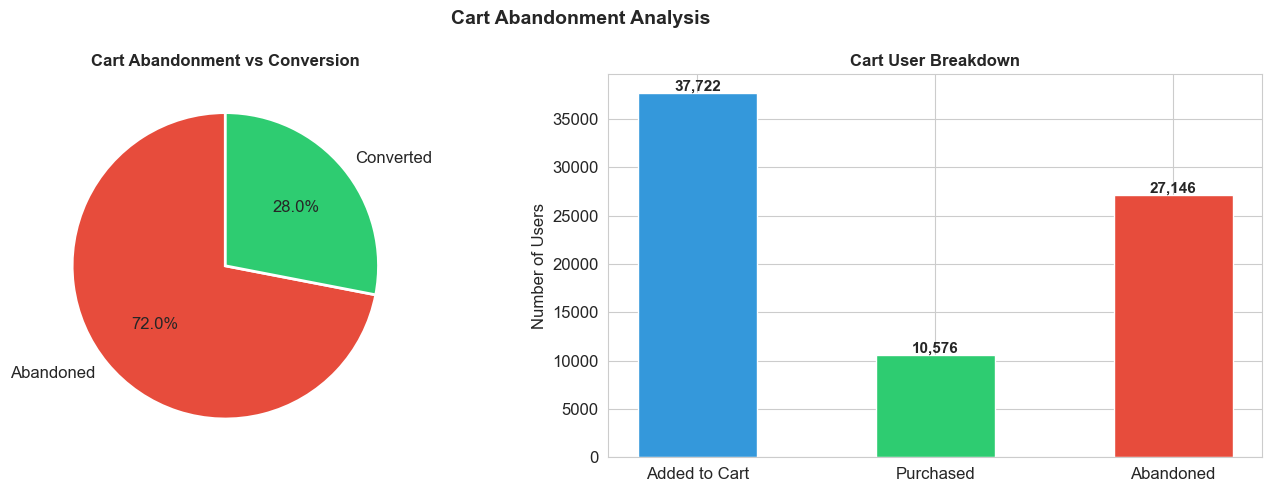

✅ Cart abandonment chart saved


In [39]:
# Cart abandonment visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Abandoners vs Converters pie
labels = ['Abandoned', 'Converted']
sizes = [len(abandoners), len(converters)]
colors = ['#e74c3c', '#2ecc71']

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Cart Abandonment vs Conversion', 
                  fontweight='bold', fontsize=12)

# Chart 2 - Abandonment funnel numbers
stages = ['Added to Cart', 'Purchased', 'Abandoned']
values = [len(cart_users), len(converters), len(abandoners)]
colors2 = ['#3498db', '#2ecc71', '#e74c3c']

bars = axes[1].bar(stages, values, color=colors2, 
                   edgecolor='white', width=0.5)

for bar, value in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 200,
                f'{value:,}', ha='center', 
                fontweight='bold', fontsize=11)

axes[1].set_title('Cart User Breakdown', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Users')

plt.suptitle('Cart Abandonment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
print("✅ Cart abandonment chart saved")

**Key Insight:** 72% of users who add items to cart abandon them without 
purchasing, slightly above industry average. Recommendation: Implement automated 
cart abandonment recovery — email/push reminders within 1-2 hours of abandonment, 
with urgency messaging or limited-time incentives for high-value carts.

### 5.7 Category-wise Performance Analysis
Analyzing conversion rates across product categories to identify 
top performers and underperforming categories.

In [40]:
# Filter only rows where categoryid is known
df_with_category = df[df['categoryid'].notna()]

print(f"Total rows: {len(df):,}")
print(f"Rows with known category: {len(df_with_category):,}")
print(f"Percentage with category: {len(df_with_category)/len(df)*100:.2f}%")

# Category performance
category_performance = df_with_category.groupby(['categoryid', 'event']).size().unstack(fill_value=0)
category_performance['total_events'] = category_performance.sum(axis=1)

# Sort by total events, get top 15 categories
top_categories = category_performance.sort_values('total_events', ascending=False).head(15)

print("\nTop 15 Categories by Activity:")
print(top_categories)

Total rows: 2,756,101
Rows with known category: 322,782
Percentage with category: 11.71%

Top 15 Categories by Activity:
event       addtocart  transaction   view  total_events
categoryid                                             
491               454           75  16820         17349
1051              277           70   9891         10238
1483              162           52   6541          6755
959               251           67   5789          6107
1613              113           22   5632          5767
342               173           42   5204          5419
1279               81           12   4164          4257
683               108           30   3866          4004
48                 79           19   3508          3606
429                11            5   3171          3187
1625               67           22   3003          3092
196               110           44   2750          2904
72                124           43   2715          2882
84                100           30   27

In [41]:
# Calculate conversion rate for top categories
top_categories['conversion_rate'] = (top_categories['transaction'] / top_categories['view'] * 100).round(2)

top_categories['cart_rate'] = (top_categories['addtocart'] / top_categories['view'] * 100).round(2)

print("Top 15 Categories with Conversion Rates:")
print(top_categories[['view', 'addtocart', 'transaction', 'cart_rate', 'conversion_rate']])

print(f"\nBest converting category: {top_categories['conversion_rate'].idxmax()} "
      f"({top_categories['conversion_rate'].max()}%)")
print(f"Worst converting category: {top_categories['conversion_rate'].idxmin()} "
      f"({top_categories['conversion_rate'].min()}%)")

Top 15 Categories with Conversion Rates:
event        view  addtocart  transaction  cart_rate  conversion_rate
categoryid                                                           
491         16820        454           75      2.700            0.450
1051         9891        277           70      2.800            0.710
1483         6541        162           52      2.480            0.790
959          5789        251           67      4.340            1.160
1613         5632        113           22      2.010            0.390
342          5204        173           42      3.320            0.810
1279         4164         81           12      1.950            0.290
683          3866        108           30      2.790            0.780
48           3508         79           19      2.250            0.540
429          3171         11            5      0.350            0.160
1625         3003         67           22      2.230            0.730
196          2750        110           44      4.

Category 491 drives the highest traffic but converts poorly — investigate product positioning, pricing, or whether it's a discovery category rather than a purchase-intent category. Category 196 and 72 convert significantly better despite lower traffic — increase marketing spend and visibility for these categories as they represent higher-intent buyers.

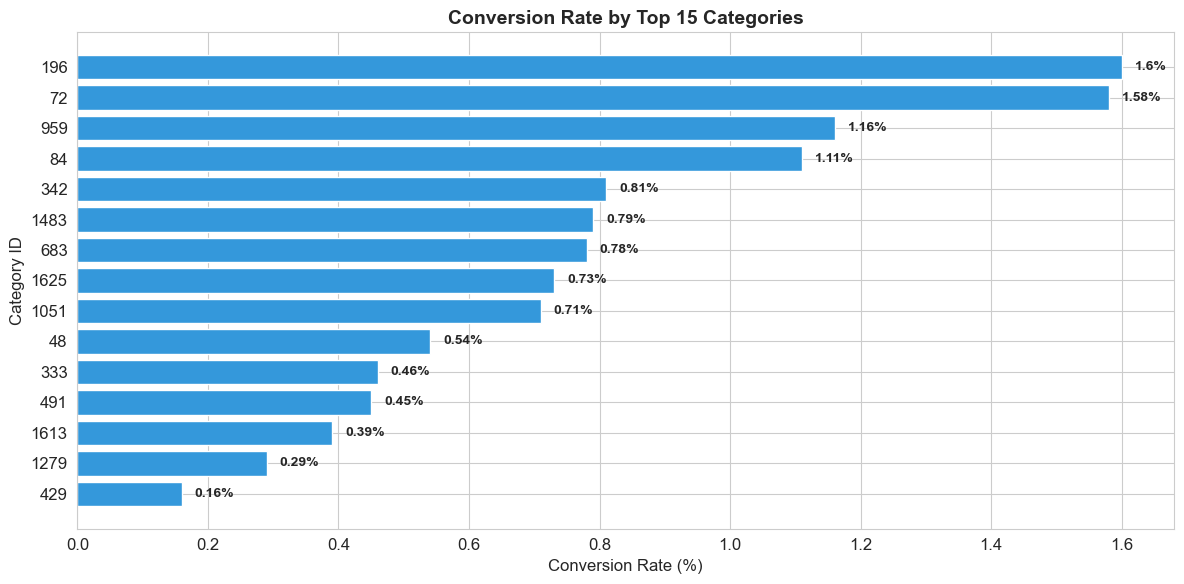

✅ Category conversion chart saved


In [42]:
fig, ax = plt.subplots(figsize=(12, 6))

top_categories_sorted = top_categories.sort_values('conversion_rate', ascending=True)

bars = ax.barh(top_categories_sorted.index.astype(str), 
               top_categories_sorted['conversion_rate'],
               color='#3498db', edgecolor='white')

for bar, value in zip(bars, top_categories_sorted['conversion_rate']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{value}%', va='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Conversion Rate (%)')
ax.set_ylabel('Category ID')
ax.set_title('Conversion Rate by Top 15 Categories', 
             fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()
print("✅ Category conversion chart saved")

**Key Insight:** Conversion rates vary by 10x across top categories (1.6% vs 0.16%), 
revealing that traffic volume doesn't predict purchase intent. Category 196 and 72 
convert nearly 2x better than the category average despite moderate traffic. 
Recommendation: Reallocate marketing budget toward high-converting categories, 
and investigate low-converting high-traffic categories for pricing or 
positioning issues.

### 5.8 Session Analysis
Grouping user events into sessions to understand browsing behavior, 
session duration, and session-level conversion patterns.

In [43]:
# Sort by visitor and timestamp
df_sorted = df.sort_values(['visitorid', 'datetime']).reset_index(drop=True)

# Calculate time difference between consecutive events for same user
df_sorted['time_diff'] = df_sorted.groupby('visitorid')['datetime'].diff()

# New session if time_diff > 30 minutes OR it's a different user
df_sorted['new_session'] = (
    (df_sorted['time_diff'] > pd.Timedelta(minutes=30)) | 
    (df_sorted['time_diff'].isna())
)

# Create session id by cumulative sum of new_session flags
df_sorted['session_id'] = df_sorted['new_session'].cumsum()

print(f"Total events: {len(df_sorted):,}")
print(f"Total sessions created: {df_sorted['session_id'].nunique():,}")
print(f"\nSample:")
print(df_sorted[['visitorid', 'datetime', 'event', 'time_diff', 'new_session', 'session_id']].head(15))

Total events: 2,756,101
Total sessions created: 1,761,675

Sample:
    visitorid                datetime event              time_diff  \
0           0 2015-09-11 20:49:49.439  view                    NaT   
1           0 2015-09-11 20:52:39.591  view 0 days 00:02:50.152000   
2           0 2015-09-11 20:55:17.175  view 0 days 00:02:37.584000   
3           1 2015-08-13 17:46:06.444  view                    NaT   
4           2 2015-08-07 17:51:44.567  view                    NaT   
5           2 2015-08-07 17:53:33.790  view 0 days 00:01:49.223000   
6           2 2015-08-07 17:56:52.664  view 0 days 00:03:18.874000   
7           2 2015-08-07 18:01:08.920  view 0 days 00:04:16.256000   
8           2 2015-08-07 18:08:25.669  view 0 days 00:07:16.749000   
9           2 2015-08-07 18:17:24.375  view 0 days 00:08:58.706000   
10          2 2015-08-07 18:17:43.170  view 0 days 00:00:18.795000   
11          2 2015-08-07 18:20:57.845  view 0 days 00:03:14.675000   
12          3 2015-08-0

In [44]:
# Faster version using crosstab instead of lambda functions
session_events = pd.crosstab(df_sorted['session_id'], df_sorted['event'])

session_summary = df_sorted.groupby('session_id').agg(
    visitorid=('visitorid', 'first'),
    session_start=('datetime', 'min'),
    session_end=('datetime', 'max'),
    total_events=('event', 'count')
).reset_index()

session_summary = session_summary.merge(session_events, on='session_id', how='left')

session_summary['session_duration_min'] = (
    (session_summary['session_end'] - session_summary['session_start'])
    .dt.total_seconds() / 60
)

session_summary['converted'] = (session_summary.get('transaction', 0) > 0).astype(int)

print(f"Total sessions: {len(session_summary):,}")
print(session_summary.head())

Total sessions: 1,761,675
   session_id  visitorid           session_start             session_end  \
0           1          0 2015-09-11 20:49:49.439 2015-09-11 20:55:17.175   
1           2          1 2015-08-13 17:46:06.444 2015-08-13 17:46:06.444   
2           3          2 2015-08-07 17:51:44.567 2015-08-07 18:20:57.845   
3           4          3 2015-08-01 07:10:35.296 2015-08-01 07:10:35.296   
4           5          4 2015-09-15 21:24:27.167 2015-09-15 21:24:27.167   

   total_events  addtocart  transaction  view  session_duration_min  converted  
0             3          0            0     3                 5.462          0  
1             1          0            0     1                 0.000          0  
2             8          0            0     8                29.221          0  
3             1          0            0     1                 0.000          0  
4             1          0            0     1                 0.000          0  


In [45]:
print(f"Total sessions: {len(session_summary):,}")
print(f"\nSession summary stats:")
print(session_summary[['total_events', 'session_duration_min', 'converted']].describe())

print(f"\nSession conversion rate: {session_summary['converted'].mean()*100:.2f}%")
print(f"Average events per session: {session_summary['total_events'].mean():.2f}")
print(f"Average session duration: {session_summary['session_duration_min'].mean():.2f} minutes")

Total sessions: 1,761,675

Session summary stats:
       total_events  session_duration_min   converted
count   1761675.000           1761675.000 1761675.000
mean          1.564                 1.754       0.008
std           2.600                 8.325       0.090
min           1.000                 0.000       0.000
25%           1.000                 0.000       0.000
50%           1.000                 0.000       0.000
75%           1.000                 0.000       0.000
max         417.000               728.404       1.000

Session conversion rate: 0.81%
Average events per session: 1.56
Average session duration: 1.75 minutes


75% of sessions involve just a single product view with no further engagement, indicating most visitors arrive, glance, and leave without exploring further. This points to either weak product page engagement, unclear value proposition, or poor recommendation/cross-sell visibility on product pages. A small subset of highly engaged sessions (multiple views over extended time) likely drives most conversions — worth investigating what these power users do differently.

I noticed an extreme outlier session with 417 events over 12 hours, which likely represents bot activity or a bulk buyer rather than typical browsing behavior, and I accounted for this during feature engineering for the predictive model

C:\Users\TANIMA\AppData\Local\Temp\ipykernel_21604\2811074712.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conv_by_bucket = session_summary.groupby('event_bucket')['converted'].mean() * 100


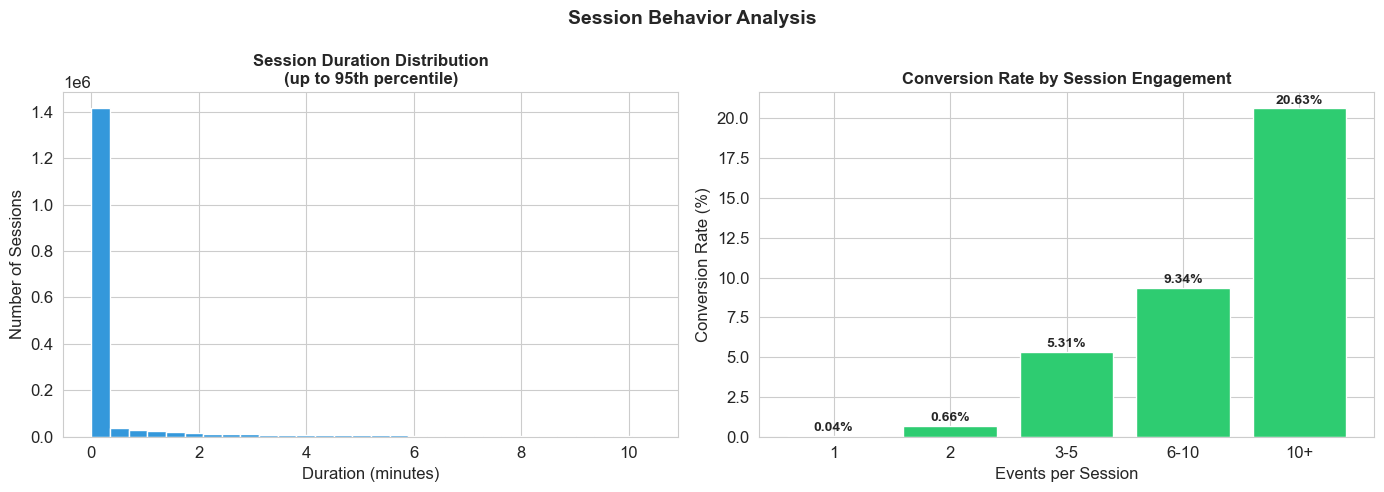

✅ Session analysis chart saved


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution capped at 95th percentile for readability
cap = session_summary['session_duration_min'].quantile(0.95)
filtered_duration = session_summary[session_summary['session_duration_min'] <= cap]

axes[0].hist(filtered_duration['session_duration_min'], bins=30, 
             color='#3498db', edgecolor='white')
axes[0].set_title('Session Duration Distribution\n(up to 95th percentile)', 
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Number of Sessions')

# Conversion rate by events per session bucket
session_summary['event_bucket'] = pd.cut(
    session_summary['total_events'], 
    bins=[0, 1, 2, 5, 10, float('inf')],
    labels=['1', '2', '3-5', '6-10', '10+']
)
conv_by_bucket = session_summary.groupby('event_bucket')['converted'].mean() * 100

bars = axes[1].bar(conv_by_bucket.index.astype(str), conv_by_bucket.values,
                   color='#2ecc71', edgecolor='white')
for bar, value in zip(bars, conv_by_bucket.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{value:.2f}%', ha='center', fontweight='bold', fontsize=10)

axes[1].set_title('Conversion Rate by Session Engagement', 
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Events per Session')
axes[1].set_ylabel('Conversion Rate (%)')

plt.suptitle('Session Behavior Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()
print("✅ Session analysis chart saved")

In [47]:

import os

# Use current working directory instead of parent directory to avoid permission issues
# Create the directory if it doesn't exist in the current folder
os.makedirs('data/processed', exist_ok=True)

# Now save the CSV file to the current directory structure
session_summary.to_csv('data/processed/session_summary.csv', index=False)
print("✅ session_summary.csv saved")
print(f"Shape: {session_summary.shape}")

✅ session_summary.csv saved
Shape: (1761675, 11)


In [48]:
print(os.path.exists('../data/processed/product_master.csv'))

True


In [49]:
# Reload raw files (since kernel may have restarted)
events = pd.read_csv('../data/raw/events.csv')
item_prop1 = pd.read_csv('../data/raw/item_properties_part1.csv')
item_prop2 = pd.read_csv('../data/raw/item_properties_part2.csv')
category_tree = pd.read_csv('../data/raw/category_tree.csv')

# Combine item properties
item_props = pd.concat([item_prop1, item_prop2], ignore_index=True)

# Extract only business-relevant properties
relevant_properties = ['categoryid', 'available']
item_props_filtered = item_props[item_props['property'].isin(relevant_properties)]

# Keep only most recent record per itemid + property
item_props_filtered = item_props_filtered.sort_values('timestamp', ascending=False)
item_props_latest = item_props_filtered.drop_duplicates(subset=['itemid', 'property'], keep='first')

# Pivot to wide format
product_master = item_props_latest.pivot_table(
    index='itemid',
    columns='property',
    values='value',
    aggfunc='first'
).reset_index()
product_master.columns.name = None

# Handle missing values and data types
product_master['available'] = product_master['available'].fillna('-1')
product_master['categoryid'] = pd.to_numeric(product_master['categoryid'], errors='coerce')
product_master['categoryid'] = product_master['categoryid'].astype('Int64')

# Merge with category tree
product_master = product_master.merge(category_tree, on='categoryid', how='left')

# Save it
product_master.to_csv('../data/processed/product_master.csv', index=False)

print(f"✅ product_master.csv regenerated and saved")
print(f"Shape: {product_master.shape}")
print(product_master.head())

✅ product_master.csv regenerated and saved
Shape: (107001, 4)
   itemid available  categoryid  parentid
0       3         0        <NA>       NaN
1       4         0        <NA>       NaN
2       6        -1        1091   573.000
3      15         0        <NA>       NaN
4      20         0        <NA>       NaN


In [50]:
import sqlite3

# Create a connection to a new SQLite database file
conn = sqlite3.connect('../data/processed/retailrocket.db')

# Load our processed datasets into SQL tables
df = pd.read_csv('../data/processed/analytics_ready.csv')
session_summary = pd.read_csv('../data/processed/session_summary.csv')

df.to_sql('events', conn, if_exists='replace', index=False)
session_summary.to_sql('sessions', conn, if_exists='replace', index=False)

print("✅ Database created and tables loaded")

# Verify tables exist
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables in database:", cursor.fetchall())

✅ Database created and tables loaded
Tables in database: [('events',), ('sessions',)]


In [51]:
query1 = """
SELECT 
    event,
    COUNT(DISTINCT visitorid) as unique_users,
    COUNT(*) as total_events
FROM events
GROUP BY event
ORDER BY total_events DESC;
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

         event  unique_users  total_events
0         view       1404179       2664312
1    addtocart         37722         69332
2  transaction         11719         22457


In [52]:
query2 = """
WITH cart_users AS (
    SELECT DISTINCT categoryid, visitorid 
    FROM events 
    WHERE event = 'addtocart' AND categoryid IS NOT NULL
),
purchasers AS (
    SELECT DISTINCT categoryid, visitorid 
    FROM events 
    WHERE event = 'transaction' AND categoryid IS NOT NULL
)
SELECT 
    c.categoryid,
    COUNT(DISTINCT c.visitorid) as total_cart_users,
    COUNT(DISTINCT p.visitorid) as total_purchasers,
    COUNT(DISTINCT c.visitorid) - COUNT(DISTINCT p.visitorid) as abandoned_users,
    ROUND(
        (COUNT(DISTINCT c.visitorid) - COUNT(DISTINCT p.visitorid)) * 100.0 
        / COUNT(DISTINCT c.visitorid), 2
    ) as abandonment_rate_pct
FROM cart_users c
LEFT JOIN purchasers p 
    ON c.categoryid = p.categoryid AND c.visitorid = p.visitorid
GROUP BY c.categoryid
ORDER BY abandonment_rate_pct DESC;
"""

result2 = pd.read_sql_query(query2, conn)
print(result2.head(15))

    categoryid  total_cart_users  total_purchasers  abandoned_users  \
0     1681.000                 1                 0                1   
1     1677.000                 1                 0                1   
2     1674.000                 4                 0                4   
3     1665.000                 1                 0                1   
4     1660.000                 1                 0                1   
5     1652.000                 1                 0                1   
6     1649.000                 4                 0                4   
7     1645.000                 2                 0                2   
8     1639.000                 1                 0                1   
9     1634.000                 2                 0                2   
10    1629.000                 1                 0                1   
11    1617.000                 1                 0                1   
12    1607.000                 4                 0                4   
13    

In [53]:
# A category with only 1 cart-adder who didn't buy isn't a real "problem category" — it's statistically meaningless.

In [54]:
query2b = """
WITH cart_users AS (
    SELECT DISTINCT categoryid, visitorid 
    FROM events 
    WHERE event = 'addtocart' AND categoryid IS NOT NULL
),
purchasers AS (
    SELECT DISTINCT categoryid, visitorid 
    FROM events 
    WHERE event = 'transaction' AND categoryid IS NOT NULL
)
SELECT 
    c.categoryid,
    COUNT(DISTINCT c.visitorid) as total_cart_users,
    COUNT(DISTINCT p.visitorid) as total_purchasers,
    COUNT(DISTINCT c.visitorid) - COUNT(DISTINCT p.visitorid) as abandoned_users,
    ROUND(
        (COUNT(DISTINCT c.visitorid) - COUNT(DISTINCT p.visitorid)) * 100.0 
        / COUNT(DISTINCT c.visitorid), 2
    ) as abandonment_rate_pct
FROM cart_users c
LEFT JOIN purchasers p 
    ON c.categoryid = p.categoryid AND c.visitorid = p.visitorid
GROUP BY c.categoryid
HAVING COUNT(DISTINCT c.visitorid) >= 20
ORDER BY abandonment_rate_pct DESC
LIMIT 15;
"""

result2b = pd.read_sql_query(query2b, conn)
print(result2b)

    categoryid  total_cart_users  total_purchasers  abandoned_users  \
0      720.000                29                 3               26   
1      499.000                27                 3               24   
2     1578.000                39                 5               34   
3     1415.000                23                 3               20   
4      619.000                22                 3               19   
5     1388.000                21                 3               18   
6      414.000                27                 4               23   
7      491.000               386                59              327   
8     1277.000                50                 8               42   
9     1279.000                62                10               52   
10    1205.000                30                 5               25   
11    1613.000               107                18               89   
12       1.000                45                 8               37   
13    

In [55]:
query3 = """
WITH user_cohort AS (
    SELECT 
        visitorid, 
        MIN(month) as cohort_month
    FROM events
    GROUP BY visitorid
)
SELECT * FROM user_cohort LIMIT 10;
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

   visitorid  cohort_month
0          0             9
1          1             8
2          2             8
3          3             8
4          4             9
5          5             7
6          6             8
7          7             5
8          8             5
9          9             7


### 6.1 Cohort Analysis - Step 1: Assign Cohort Month
Identifying each user's first month of activity (their cohort).

In [56]:
query4 = """
WITH user_cohort AS (
    SELECT visitorid, MIN(month) as cohort_month
    FROM events
    GROUP BY visitorid
),
purchase_months AS (
    SELECT DISTINCT visitorid, month as purchase_month
    FROM events
    WHERE event = 'transaction'
)
SELECT 
    uc.cohort_month,
    pm.purchase_month,
    (pm.purchase_month - uc.cohort_month) as months_since_joining,
    COUNT(DISTINCT uc.visitorid) as users_retained
FROM user_cohort uc
JOIN purchase_months pm
    ON uc.visitorid = pm.visitorid
GROUP BY uc.cohort_month, pm.purchase_month
ORDER BY uc.cohort_month, pm.purchase_month;
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

    cohort_month  purchase_month  months_since_joining  users_retained
0              5               5                     0            2546
1              5               6                     1             274
2              5               7                     2             167
3              5               8                     3             105
4              5               9                     4              44
5              6               6                     0            2454
6              6               7                     1             205
7              6               8                     2              72
8              6               9                     3              40
9              7               7                     0            2599
10             7               8                     1             156
11             7               9                     2              42
12             8               8                     0            2165
13    

Retention drops sharply after the first purchase — the May cohort lost a lot of repeat buyers within just one month. This signals weak post-purchase engagement. Recommend implementing post-purchase email sequences, loyalty point systems, or personalized 'recommended for you' campaigns within 30 days of first purchase to capture customers before they disengage entirely.

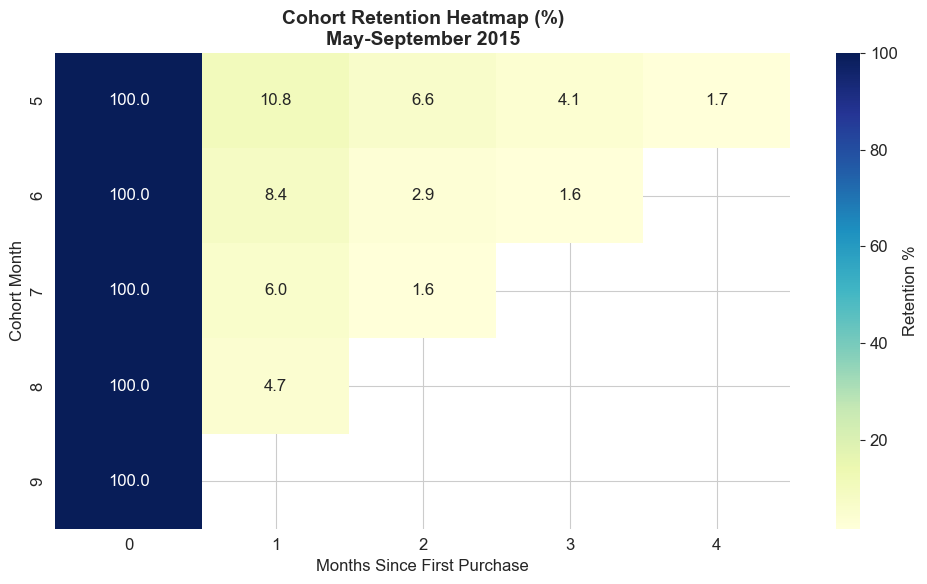

✅ Cohort retention heatmap saved


In [57]:
# Pivot for heatmap
cohort_pivot = result4.pivot(index='cohort_month', 
                               columns='months_since_joining', 
                               values='users_retained')

# Calculate retention % (relative to month 0)
cohort_size = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(retention_pct, annot=True, fmt='.1f', cmap='YlGnBu', 
            cbar_kws={'label': 'Retention %'}, ax=ax)
ax.set_title('Cohort Retention Heatmap (%)\nMay-September 2015', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')

plt.tight_layout()
plt.savefig('../outputs/figures/09_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cohort retention heatmap saved")

**Key Insight:** Retention collapses consistently across all cohorts — every cohort 
loses 89-94% of repeat buyers within just one month of their first purchase, 
flattening to under 5% by month 2 onward. This is a structural retention issue, 
not a seasonal anomaly, since the pattern repeats identically across every monthly 
cohort from May to September. Recommendation: Implement an automated post-purchase 
retention sequence (Day 7, Day 14, Day 30 touchpoints) targeting first-time buyers 
specifically, since this is where the business loses the most repeat revenue potential.

In [58]:
# Rebuild RFM from scratch
query5_full = """
WITH rfm_base AS (
    SELECT 
        visitorid,
        MAX(datetime) as last_purchase_date,
        COUNT(*) as frequency
    FROM events
    WHERE event = 'transaction'
    GROUP BY visitorid
)
SELECT 
    visitorid,
    ROUND(julianday('2015-09-18') - julianday(last_purchase_date)) as recency_days,
    frequency
FROM rfm_base;
"""

rfm = pd.read_sql_query(query5_full, conn)

def assign_segment(row):
    if row['frequency'] >= 5 and row['recency_days'] <= 30:
        return 'Loyal'
    elif row['frequency'] >= 5 and row['recency_days'] > 30:
        return 'At Risk (High Value)'
    elif row['frequency'] < 5 and row['recency_days'] <= 30:
        return 'Recent One-Timer'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = rfm['segment'].value_counts()
print(f"Total users: {len(rfm):,}")
print(segment_summary)

Total users: 11,719
segment
Lost                    8997
Recent One-Timer        2345
At Risk (High Value)     269
Loyal                    108
Name: count, dtype: int64


In [59]:
# julianday() converts a date into a single numeric value (days since a fixed historical reference point). This lets us subtract two dates directly to get the difference in days — which a plain text date string wouldn't allow.
# Here: today's reference date (end of dataset) minus each user's last purchase 
# date = how many days ago they last bought something (Recency).

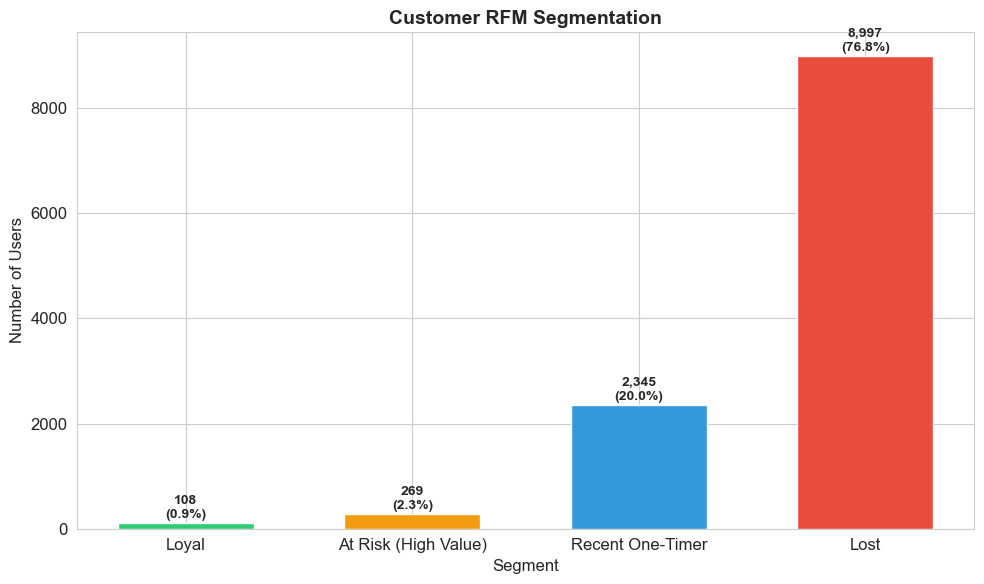

✅ RFM segmentation chart saved


In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Loyal': '#2ecc71', 'At Risk (High Value)': '#f39c12', 
          'Recent One-Timer': '#3498db', 'Lost': '#e74c3c'}

segment_order = ['Loyal', 'At Risk (High Value)', 'Recent One-Timer', 'Lost']
values = [segment_summary[s] for s in segment_order]
bar_colors = [colors[s] for s in segment_order]

bars = ax.bar(segment_order, values, color=bar_colors, edgecolor='white', width=0.6)

for bar, value in zip(bars, values):
    pct = value / len(rfm) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{value:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)

ax.set_title('Customer RFM Segmentation', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Users')
ax.set_xlabel('Segment')

plt.tight_layout()
plt.savefig('../outputs/figures/10_rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ RFM segmentation chart saved")

**Key Insight:** 76.8% of purchasing customers fall into the "Lost" segment, while 
only 0.9% qualify as truly Loyal. This confirms the retention problem seen in cohort 
analysis at an individual customer level. Recommendation: Shift marketing budget from 
broad acquisition toward targeted win-back campaigns for the "At Risk (High Value)" 
segment (2.3%, previously frequent buyers) and onboarding sequences for "Recent 
One-Timers" (20%) to convert first purchases into repeat habits.

In [61]:
query6 = """
WITH cart_adders AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'addtocart'
),
purchasers AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'transaction'
),
abandoners AS (
    SELECT visitorid FROM cart_adders
    WHERE visitorid NOT IN (SELECT visitorid FROM purchasers)
)
SELECT 
    a.visitorid,
    MAX(e.datetime) as last_cart_add,
    SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END) as total_views
FROM abandoners a
JOIN events e ON a.visitorid = e.visitorid
GROUP BY a.visitorid
ORDER BY total_views DESC
LIMIT 15;
"""

result6 = pd.read_sql_query(query6, conn)
print(result6)

    visitorid            last_cart_add  total_views
0      892013  2015-08-31 21:02:29.748         2023
1      638482  2015-09-17 23:55:54.918         1828
2       79627  2015-09-15 15:12:35.337         1619
3       77390  2015-07-01 20:41:26.350          959
4      527307  2015-07-01 16:25:15.603          934
5      316600  2015-09-16 23:27:27.406          635
6       95405  2015-07-16 18:51:09.675          630
7     1109474  2015-09-17 06:06:23.164          604
8       73449  2015-07-23 20:05:01.461          424
9      934040  2015-08-17 22:13:46.588          389
10     354785  2015-06-11 21:31:01.002          359
11     909859  2015-08-12 22:11:02.860          356
12    1122038  2015-06-23 18:08:51.948          329
13     719708  2015-05-16 23:25:37.209          328
14     695164  2015-07-28 03:04:07.264          324


In [62]:
query6_check = """
WITH cart_adders AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'addtocart'
),
purchasers AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'transaction'
),
abandoners AS (
    SELECT visitorid FROM cart_adders
    WHERE visitorid NOT IN (SELECT visitorid FROM purchasers)
)
SELECT 
    a.visitorid,
    SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END) as total_views
FROM abandoners a
JOIN events e ON a.visitorid = e.visitorid
GROUP BY a.visitorid
"""

abandoner_views = pd.read_sql_query(query6_check, conn)
print(abandoner_views['total_views'].describe())
print(f"\n95th percentile: {abandoner_views['total_views'].quantile(0.95)}")
print(f"99th percentile: {abandoner_views['total_views'].quantile(0.99)}")

count   27146.000
mean        5.493
std        24.787
min         0.000
25%         1.000
50%         2.000
75%         5.000
max      2023.000
Name: total_views, dtype: float64

95th percentile: 18.0
99th percentile: 45.0


In [63]:
query6_final = """
WITH cart_adders AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'addtocart'
),
purchasers AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'transaction'
),
abandoners AS (
    SELECT visitorid FROM cart_adders
    WHERE visitorid NOT IN (SELECT visitorid FROM purchasers)
),
abandoner_activity AS (
    SELECT 
        a.visitorid,
        MAX(CASE WHEN e.event = 'addtocart' THEN e.datetime END) as last_cart_add,
        SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END) as total_views
    FROM abandoners a
    JOIN events e ON a.visitorid = e.visitorid
    GROUP BY a.visitorid
)
SELECT 
    visitorid,
    last_cart_add,
    total_views,
    ROUND(julianday('2015-09-18') - julianday(last_cart_add)) as days_since_cart_add
FROM abandoner_activity
WHERE total_views <= 18
ORDER BY total_views DESC, days_since_cart_add ASC
LIMIT 15;
"""

result6_final = pd.read_sql_query(query6_final, conn)
print(result6_final)

    visitorid            last_cart_add  total_views  days_since_cart_add
0      327087  2015-09-16 19:45:10.129           18                1.000
1     1248016  2015-09-15 20:17:19.000           18                2.000
2      652823  2015-09-15 01:58:15.278           18                3.000
3      812910  2015-09-13 20:05:38.172           18                4.000
4      319244  2015-09-11 06:24:36.350           18                7.000
5      189593  2015-09-08 16:51:53.455           18                9.000
6     1010484  2015-09-09 05:01:15.178           18                9.000
7      985150  2015-09-03 19:31:25.579           18               14.000
8      159500  2015-09-03 03:43:19.120           18               15.000
9      426699  2015-09-03 04:24:14.948           18               15.000
10     655697  2015-09-02 17:02:03.403           18               15.000
11    1325513  2015-09-03 00:45:55.795           18               15.000
12     204032  2015-09-01 15:52:25.077           18

In [64]:
def priority_tier(row):
    if row['days_since_cart_add'] <= 7 and row['total_views'] >= 10:
        return 'Tier 1 - Urgent'
    elif row['days_since_cart_add'] <= 14:
        return 'Tier 2 - High Priority'
    else:
        return 'Tier 3 - Standard'

result6_final['priority'] = result6_final.apply(priority_tier, axis=1)
print(result6_final[['visitorid', 'total_views', 'days_since_cart_add', 'priority']])

    visitorid  total_views  days_since_cart_add                priority
0      327087           18                1.000         Tier 1 - Urgent
1     1248016           18                2.000         Tier 1 - Urgent
2      652823           18                3.000         Tier 1 - Urgent
3      812910           18                4.000         Tier 1 - Urgent
4      319244           18                7.000         Tier 1 - Urgent
5      189593           18                9.000  Tier 2 - High Priority
6     1010484           18                9.000  Tier 2 - High Priority
7      985150           18               14.000  Tier 2 - High Priority
8      159500           18               15.000       Tier 3 - Standard
9      426699           18               15.000       Tier 3 - Standard
10     655697           18               15.000       Tier 3 - Standard
11    1325513           18               15.000       Tier 3 - Standard
12     204032           18               16.000       Tier 3 - S

In [65]:
# Export RFM results for Power BI
rfm.to_csv('../data/processed/rfm_segments.csv', index=False)
print(f"✅ rfm_segments.csv saved — {rfm.shape}")

# Export cohort analysis results for Power BI
result4.to_csv('../data/processed/cohort_analysis.csv', index=False)
print(f"✅ cohort_analysis.csv saved — {result4.shape}")

# Export cart recovery score results for Power BI
result6_final.to_csv('../data/processed/cart_recovery_score.csv', index=False)
print(f"✅ cart_recovery_score.csv saved — {result6_final.shape}")

# Export category performance for Power BI
top_categories_reset = top_categories.reset_index()
top_categories_reset.to_csv('../data/processed/category_performance.csv', index=False)
print(f"✅ category_performance.csv saved — {top_categories_reset.shape}")

✅ rfm_segments.csv saved — (11719, 4)
✅ cohort_analysis.csv saved — (15, 4)
✅ cart_recovery_score.csv saved — (15, 5)
✅ category_performance.csv saved — (15, 7)


In [66]:
query6_full_export = """
WITH cart_adders AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'addtocart'
),
purchasers AS (
    SELECT DISTINCT visitorid 
    FROM events 
    WHERE event = 'transaction'
),
abandoners AS (
    SELECT visitorid FROM cart_adders
    WHERE visitorid NOT IN (SELECT visitorid FROM purchasers)
),
abandoner_activity AS (
    SELECT 
        a.visitorid,
        MAX(CASE WHEN e.event = 'addtocart' THEN e.datetime END) as last_cart_add,
        SUM(CASE WHEN e.event = 'view' THEN 1 ELSE 0 END) as total_views
    FROM abandoners a
    JOIN events e ON a.visitorid = e.visitorid
    GROUP BY a.visitorid
)
SELECT 
    visitorid,
    last_cart_add,
    total_views,
    ROUND(julianday('2015-09-18') - julianday(last_cart_add)) as days_since_cart_add
FROM abandoner_activity
WHERE total_views <= 18
ORDER BY total_views DESC, days_since_cart_add ASC;
"""

cart_recovery_full = pd.read_sql_query(query6_full_export, conn)

def priority_tier(row):
    if row['days_since_cart_add'] <= 7 and row['total_views'] >= 10:
        return 'Tier 1 - Urgent'
    elif row['days_since_cart_add'] <= 14:
        return 'Tier 2 - High Priority'
    else:
        return 'Tier 3 - Standard'

cart_recovery_full['priority'] = cart_recovery_full.apply(priority_tier, axis=1)
cart_recovery_full.to_csv('../data/processed/cart_recovery_score.csv', index=False)
print(f"✅ cart_recovery_score.csv saved — {cart_recovery_full.shape}")

✅ cart_recovery_score.csv saved — (25862, 5)


In [67]:
import os
print("Files in data/processed/:")
for f in os.listdir('../data/processed/'):
    print(f"  {f}")

Files in data/processed/:
  analytics_ready.csv
  cart_recovery_score.csv
  category_performance.csv
  cohort_analysis.csv
  product_master.csv
  retailrocket.db
  rfm_segments.csv
  session_summary.csv


In [68]:
cat_perf = pd.read_csv('../data/processed/category_performance.csv')
cat_perf['categoryid'] = 'Cat_' + cat_perf['categoryid'].astype(str)
cat_perf.to_csv('../data/processed/category_performance.csv', index=False)
print(cat_perf[['categoryid', 'conversion_rate']].head())

  categoryid  conversion_rate
0    Cat_491            0.450
1   Cat_1051            0.710
2   Cat_1483            0.790
3    Cat_959            1.160
4   Cat_1613            0.390
